# Results Analysis — Final Plots, Summary Tables, Qualitative Examples
Aggregates FEVER poisoning sweep (nb05) and prompt ablation + self-consistency (nb06) into report-ready figures and tables. No new API calls.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

with open("../configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

SEED            = cfg["seed"]
K               = cfg["retrieval"]["k"]
DISTRACTOR_POOL = cfg["retrieval"]["distractor_pool_size"]
EMBEDDING_MODEL = cfg["retrieval"]["embedding_model"]
EMB_CACHE       = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["embeddings_subdir"])
LLM_CACHE       = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["llm_subdir"])

MODELS          = cfg["models"]["available"]
PROMPT_TYPES    = ["standard", "chain_of_thought", "vigilant"]
POISON_RATES    = [0.0, 0.25, 0.5, 0.75, 1.0]
TEMPERATURE     = cfg["models"]["temperature"]
TEMP_SC         = cfg["models"]["temperature_consistency"]
N_EXAMPLES      = cfg["evaluation"]["n_examples"]
N_SC            = cfg["evaluation"]["self_consistency_subset"]
SC_RUNS         = cfg["evaluation"]["self_consistency_runs"]


from nb_style import MODEL_LABELS, MODEL_COLORS, MODEL_LS, MODEL_MARKERS, PROMPT_COLORS

os.makedirs("../figures", exist_ok=True)
print("Config loaded.")

Config loaded.


## 1. Reproduce all data from cache

Re-run the scorer for every condition. All calls hit the disk cache: no new API cost.

In [2]:
from src.data.fever_loader import load_fever
from src.data.poisoner import poison_dataset
from src.retrieval.embedder import Embedder
from src.retrieval.retriever import Retriever
from src.generation.llm_client import HuggingFaceClient
from src.evaluation.scorer import run as run_scorer

all_examples = load_fever("../" + cfg["dataset"]["fever_dev"])
examples     = all_examples[:N_EXAMPLES]
examples_sc  = all_examples[:N_SC]

embedder = Embedder(model_name=EMBEDDING_MODEL, cache_dir=EMB_CACHE)


def build_llm(model: str, temperature: float = 0.0):
    return HuggingFaceClient(model=model, temperature=temperature, cache_dir=LLM_CACHE)


# --- Phase A: full poisoning sweep (nb05 replica) ---
rows_main = []
for model_name in MODELS:
    llm = build_llm(model_name, TEMPERATURE)
    with llm:
        for pr in POISON_RATES:
            poisoned = poison_dataset(examples, poison_rate=pr, seed=SEED) if pr > 0 else examples
            for pt in PROMPT_TYPES:
                retriever = Retriever(embedder=embedder, k=K)
                m = run_scorer(poisoned, retriever, llm, prompt_type=pt,
                               distractor_pool_size=DISTRACTOR_POOL, seed=SEED,
                               self_consistency_runs=1)
                rows_main.append({"model": model_name, "poison_rate": pr, "prompt_type": pt, **m})
    print(f"  {MODEL_LABELS[model_name]} sweep done")

df_main = pd.DataFrame(rows_main)
print(f"Main sweep: {len(df_main)} conditions (all cached).")

# --- Phase B: self-consistency at poison_rate=0.5 (nb06 replica) ---
rows_sc = []
poisoned_sc = poison_dataset(examples_sc, poison_rate=0.5, seed=SEED)
for model_name in MODELS:
    llm = build_llm(model_name, TEMP_SC)
    with llm:
        for pt in PROMPT_TYPES:
            retriever = Retriever(embedder=embedder, k=K)
            m = run_scorer(poisoned_sc, retriever, llm, prompt_type=pt,
                           distractor_pool_size=DISTRACTOR_POOL, seed=SEED,
                           self_consistency_runs=SC_RUNS)
            rows_sc.append({"model": model_name, "prompt_type": pt,
                            "self_consistency": m["self_consistency"]})
    print(f"  {MODEL_LABELS[model_name]} self-consistency done")

df_sc = pd.DataFrame(rows_sc)
embedder.close()
print(f"Self-consistency: {len(df_sc)} conditions.")

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  Qwen2.5 sweep done
  Gemma-2 sweep done
  SmolLM2 sweep done
  Phi-3.5 sweep done
  Llama-3.2 sweep done
Main sweep: 75 conditions (all cached).
  Qwen2.5 self-consistency done
  Gemma-2 self-consistency done
  SmolLM2 self-consistency done
  Phi-3.5 self-consistency done
  Llama-3.2 self-consistency done
Self-consistency: 15 conditions.


## 2. Grand Summary Table

All metrics across every condition, sorted by model and poison rate.

In [3]:
# Merge self-consistency (measured at poison_rate=0.5) into the main table
df = df_main.merge(df_sc, on=["model", "prompt_type"], how="left")

# Add short model name
df["model_short"] = df["model"].map(MODEL_LABELS)

# Display full table
display_cols = ["model_short", "poison_rate", "prompt_type",
                "accuracy", "macro_f1", "hallucination_rate", "precision_at_k", "self_consistency"]
table = df[display_cols].copy()
table.columns = ["Model", "Poison Rate", "Prompt", "Accuracy", "Macro-F1",
                  "Hallucination", "P@k", "Self-Consistency"]
print(f"=== Grand Summary Table (N={N_EXAMPLES}, k={K}) ===")
print(f"    Self-consistency measured at poison_rate=0.5, temp={TEMP_SC}, sc_runs={SC_RUNS}, N={N_SC}")
print()
print(table.to_string(index=False, float_format="{:.3f}".format))

=== Grand Summary Table (N=50, k=5) ===
    Self-consistency measured at poison_rate=0.5, temp=0.7, sc_runs=5, N=30

    Model  Poison Rate           Prompt  Accuracy  Macro-F1  Hallucination   P@k  Self-Consistency
  Qwen2.5        0.000         standard     0.500     0.486          0.235 0.208             0.733
  Qwen2.5        0.000 chain_of_thought     0.580     0.493          0.118 0.208             0.807
  Qwen2.5        0.000         vigilant     0.360     0.213          0.000 0.208             0.860
  Qwen2.5        0.250         standard     0.420     0.379          0.235 0.156             0.733
  Qwen2.5        0.250 chain_of_thought     0.540     0.439          0.118 0.156             0.807
  Qwen2.5        0.250         vigilant     0.340     0.172          0.000 0.156             0.860
  Qwen2.5        0.500         standard     0.500     0.442          0.059 0.132             0.733
  Qwen2.5        0.500 chain_of_thought     0.500     0.431          0.000 0.132           

## 3. Accuracy Degradation: Robustness Delta
Accuracy loss relative to clean baseline (poison_rate=0%). Smaller delta = more robust.

Saved -> figures/05_accuracy_delta.png


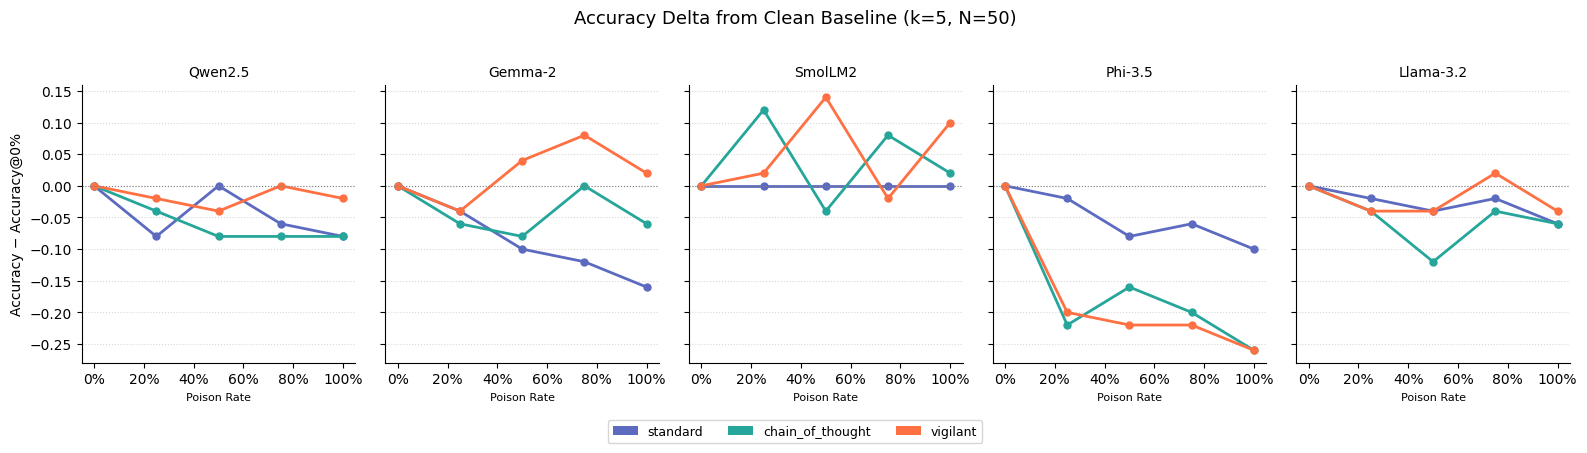

In [4]:
# Compute delta from clean baseline for each (model, prompt_type) pair
baselines = df_main[df_main["poison_rate"] == 0.0].set_index(["model", "prompt_type"])["accuracy"]
df_main["acc_delta"] = df_main.apply(
    lambda r: r["accuracy"] - baselines.loc[(r["model"], r["prompt_type"])], axis=1
)

fig, axes = plt.subplots(1, len(MODELS), figsize=(16, 4), sharey=True)
fig.suptitle(f"Accuracy Delta from Clean Baseline (k={K}, N={N_EXAMPLES})", fontsize=13, y=1.02)

for ax, model in zip(axes, MODELS):
    for pt in PROMPT_TYPES:
        sub = df_main[(df_main["model"] == model) & (df_main["prompt_type"] == pt)]
        sub = sub.sort_values("poison_rate")
        ax.plot(sub["poison_rate"], sub["acc_delta"],
                marker="o", linewidth=2, markersize=5,
                color=PROMPT_COLORS[pt], linestyle="-", label=pt)
    ax.axhline(0, color="grey", linewidth=0.8, linestyle=":")
    ax.set_title(MODEL_LABELS[model], fontsize=10)
    ax.set_xlabel("Poison Rate", fontsize=8)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle=":", alpha=0.5)

axes[0].set_ylabel("Accuracy − Accuracy@0%")
handles = [mpatches.Patch(facecolor=PROMPT_COLORS[pt], label=pt) for pt in PROMPT_TYPES]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig("../figures/05_accuracy_delta.png", dpi=150, bbox_inches="tight")
print("Saved -> figures/05_accuracy_delta.png")
plt.show()

## 4. Hallucination vs Accuracy: Scatter
Each point is one (model, prompt_type, poison_rate) condition. Ideal = top-left (high accuracy, low hallucination).

Saved -> figures/05_hallucination_vs_accuracy.png


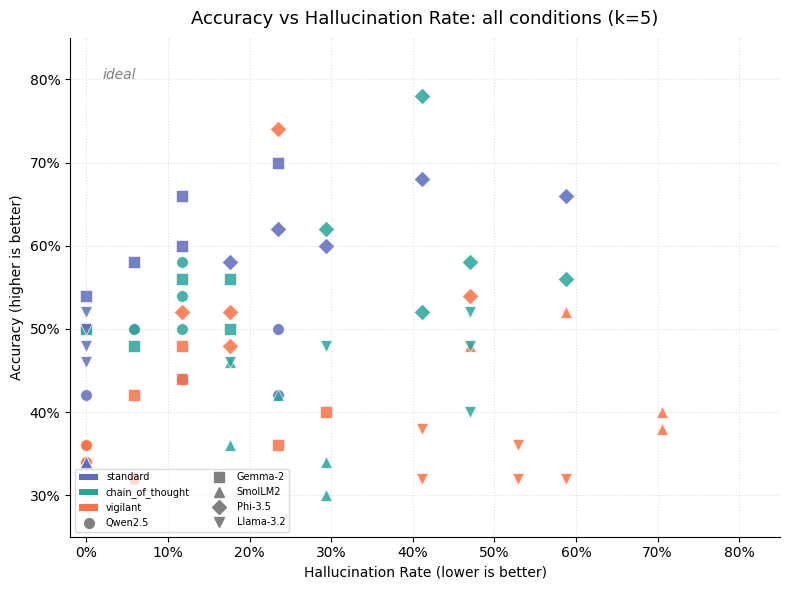

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

for model in MODELS:
    for pt in PROMPT_TYPES:
        sub = df_main[(df_main["model"] == model) & (df_main["prompt_type"] == pt)]
        ax.scatter(sub["hallucination_rate"], sub["accuracy"],
                   c=PROMPT_COLORS[pt], marker=MODEL_MARKERS[model],
                   s=70, alpha=0.85, edgecolors="white", linewidth=0.5)

ax.set_xlabel("Hallucination Rate (lower is better)")
ax.set_ylabel("Accuracy (higher is better)")
ax.set_title(f"Accuracy vs Hallucination Rate: all conditions (k={K})", fontsize=13, pad=10)
ax.set_xlim(-0.02, 0.85)
ax.set_ylim(0.25, 0.85)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(linestyle=":", alpha=0.4)
ax.annotate("ideal", xy=(0.02, 0.80), fontsize=10, fontstyle="italic", color="grey")

prompt_handles = [mpatches.Patch(facecolor=PROMPT_COLORS[pt], label=pt) for pt in PROMPT_TYPES]
model_handles  = [plt.Line2D([0], [0], marker=MODEL_MARKERS[m], color="grey",
                              linestyle="None", markersize=7, label=MODEL_LABELS[m])
                  for m in MODELS]
ax.legend(handles=prompt_handles + model_handles, fontsize=7, loc="lower left", ncol=2, framealpha=0.7)

plt.tight_layout()
plt.savefig("../figures/05_hallucination_vs_accuracy.png", dpi=150, bbox_inches="tight")
print("Saved -> figures/05_hallucination_vs_accuracy.png")
plt.show()

## 5. Heatmap: Mean Accuracy by Prompt x Model (averaged over all poison rates)

Collapses the poison-rate dimension to show the overall ranking of conditions.

Saved -> figures/05_metric_heatmaps.png


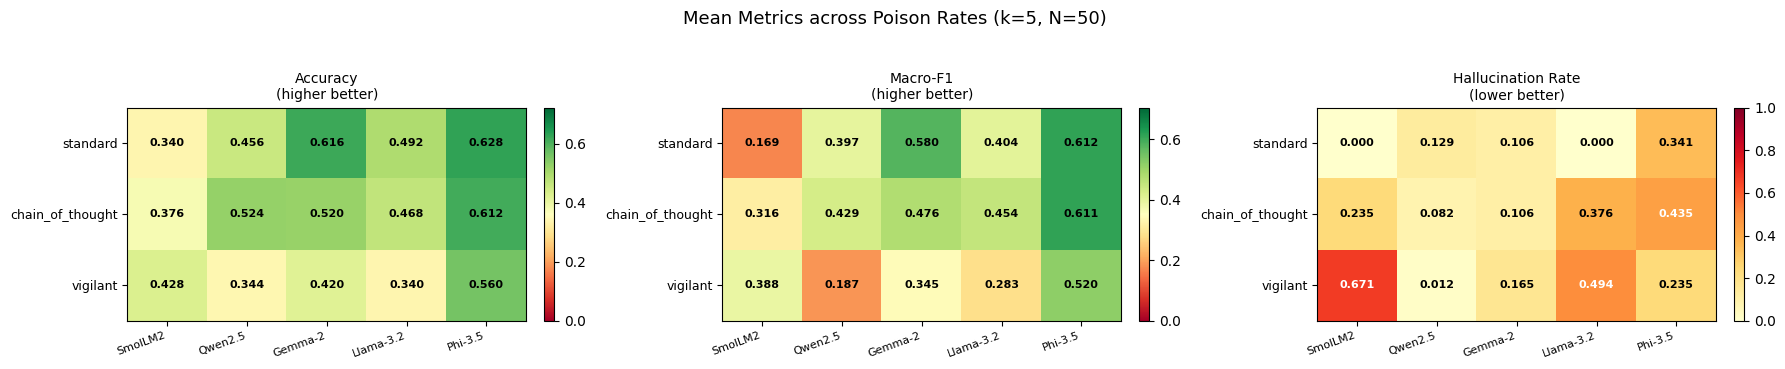

In [6]:
# 3-metric heatmap grid: accuracy, macro-f1, hallucination
metrics_cfg = [
    ("accuracy",           "Accuracy",           "RdYlGn",  True),
    ("macro_f1",           "Macro-F1",            "RdYlGn",  True),
    ("hallucination_rate", "Hallucination Rate",  "YlOrRd",  False),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 3.5))

for ax, (col, title, cmap, higher_better) in zip(axes, metrics_cfg):
    pivot = df_main.pivot_table(index="prompt_type", columns="model",
                                values=col, aggfunc="mean")
    pivot = pivot.reindex(PROMPT_TYPES)
    pivot.columns = [MODEL_LABELS[c] for c in pivot.columns]

    im = ax.imshow(pivot.values, cmap=cmap, vmin=0, vmax=1 if "rate" in col else pivot.values.max() * 1.15,
                   aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=8, rotation=20, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)

    arrow = "higher better" if higher_better else "lower better"
    ax.set_title(f"{title}\n({arrow})", fontsize=10, pad=6)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                    fontsize=8, fontweight="bold",
                    color="white" if (higher_better and v > 0.7) or (not higher_better and v > 0.4) else "black")

fig.suptitle(f"Mean Metrics across Poison Rates (k={K}, N={N_EXAMPLES})", fontsize=13, y=1.04)
plt.tight_layout()
plt.savefig("../figures/05_metric_heatmaps.png", dpi=150, bbox_inches="tight")
print("Saved -> figures/05_metric_heatmaps.png")
plt.show()

## 6. Accuracy by Poison Rate — Per Model and Averaged
At 100% poisoning (P@k=0) no parametric-knowledge recovery is observed: models default to NOT ENOUGH INFO rather than drawing on internal knowledge. The 25-75% regime remains the most dangerous.

Saved -> figures/05_non_monotonic_mean.png


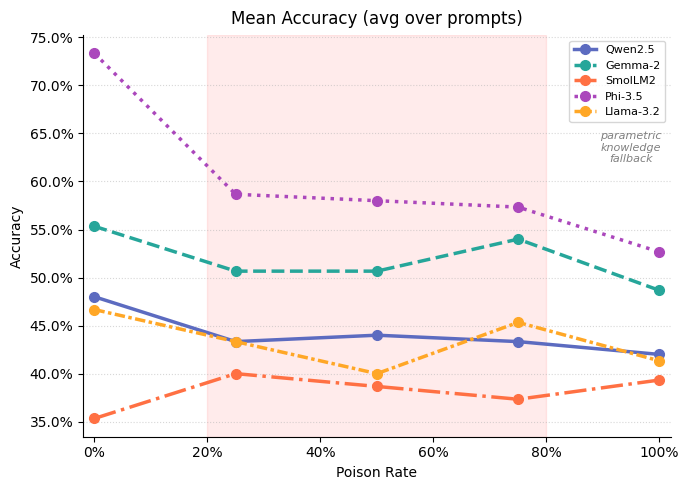

Saved -> figures/05_non_monotonic_accuracy.png


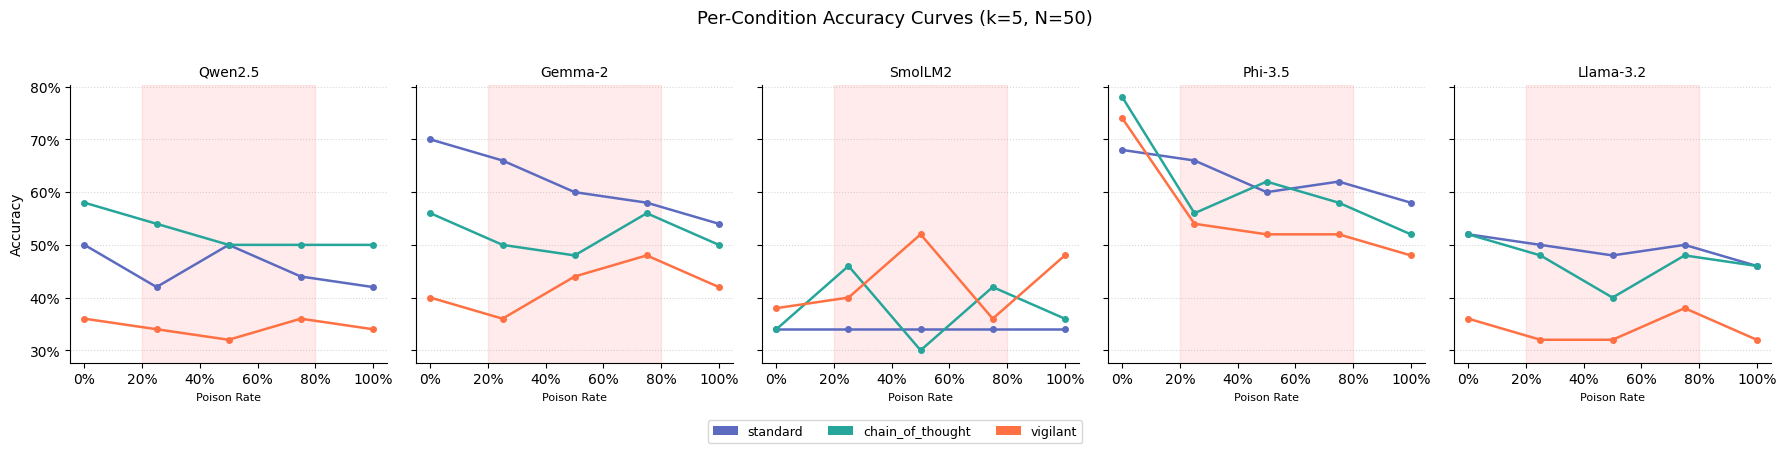

In [7]:
# Average accuracy across prompts per model
avg_by_model = df_main.groupby(["model", "poison_rate"])["accuracy"].mean().reset_index()

# Figure 1: mean accuracy per model (U-shape overview)
fig1, ax1 = plt.subplots(figsize=(7, 5))
for model in MODELS:
    sub = avg_by_model[avg_by_model["model"] == model].sort_values("poison_rate")
    ax1.plot(sub["poison_rate"], sub["accuracy"],
             marker="o", linewidth=2.5, markersize=7,
             linestyle=MODEL_LS[model], color=MODEL_COLORS[model],
             label=MODEL_LABELS[model])
ax1.set_title("Mean Accuracy (avg over prompts)", fontsize=12, pad=8)
ax1.set_xlabel("Poison Rate")
ax1.set_ylabel("Accuracy")
ax1.set_xlim(-0.02, 1.02)
ax1.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.legend(fontsize=8)
ax1.spines[["top", "right"]].set_visible(False)
ax1.grid(axis="y", linestyle=":", alpha=0.5)
ax1.axvspan(0.20, 0.80, alpha=0.08, color="red")
ax1.annotate("parametric\nknowledge\nfallback", xy=(0.95, 0.62), fontsize=8,
             fontstyle="italic", color="grey", ha="center")
fig1.tight_layout()
fig1.savefig("../figures/05_non_monotonic_mean.png", dpi=150, bbox_inches="tight")
print("Saved -> figures/05_non_monotonic_mean.png")
plt.show()

# Figure 2: per-condition accuracy: faceted by model (1×5)
fig2, axes2 = plt.subplots(1, len(MODELS), figsize=(18, 4), sharey=True)
fig2.suptitle(f"Per-Condition Accuracy Curves (k={K}, N={N_EXAMPLES})", fontsize=13, y=1.02)
for ax, model in zip(axes2, MODELS):
    for pt in PROMPT_TYPES:
        sub = df_main[(df_main["model"] == model) & (df_main["prompt_type"] == pt)]
        sub = sub.sort_values("poison_rate")
        ax.plot(sub["poison_rate"], sub["accuracy"],
                marker="o", linewidth=1.8, markersize=4,
                color=PROMPT_COLORS[pt], linestyle="-", label=pt)
    ax.axvspan(0.20, 0.80, alpha=0.08, color="red")
    ax.set_title(MODEL_LABELS[model], fontsize=10)
    ax.set_xlabel("Poison Rate", fontsize=8)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle=":", alpha=0.5)
axes2[0].set_ylabel("Accuracy")
handles = [mpatches.Patch(facecolor=PROMPT_COLORS[pt], label=pt) for pt in PROMPT_TYPES]
fig2.legend(handles=handles, loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.08))
fig2.tight_layout()
fig2.savefig("../figures/05_non_monotonic_accuracy.png", dpi=150, bbox_inches="tight")
print("Saved -> figures/05_non_monotonic_accuracy.png")
plt.show()

## 7. Retrieval Quality vs. Accuracy: Correlation Analysis
Pearson/Spearman correlation between P@k and accuracy across all (model, prompt_type, poison_rate) conditions.

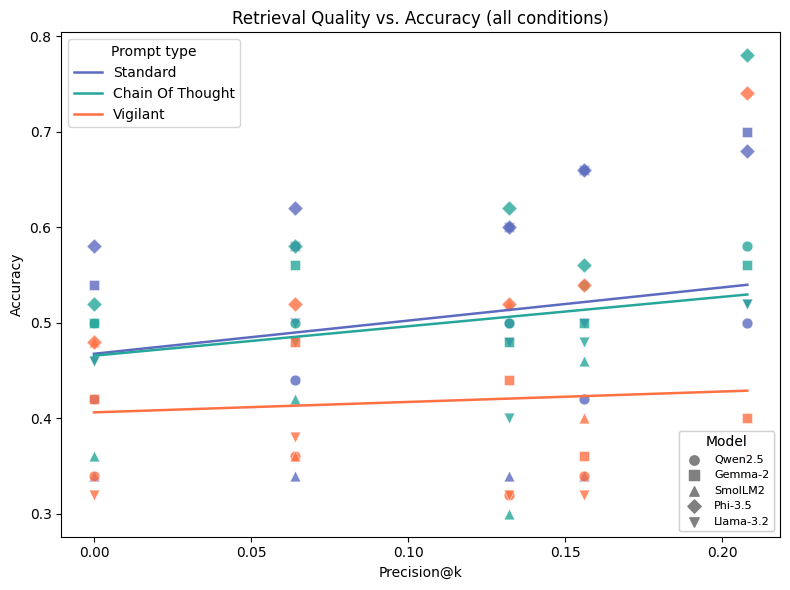

Global  Pearson r=0.169  p=0.1464
Global Spearman r=0.136  p=0.2446

                  Pearson r  Pearson p  Spearman r  Spearman p
Prompt                                                        
standard              0.224     0.2825       0.237      0.2542
chain_of_thought      0.236     0.2562       0.256      0.2159
vigilant              0.082     0.6962       0.000      1.0000


In [8]:
from src.evaluation.metrics import retrieval_accuracy_correlation

fig, ax = plt.subplots(figsize=(8, 6))

for pt in PROMPT_TYPES:
    sub = df_main[df_main['prompt_type'] == pt]
    for model in MODELS:
        s = sub[sub['model'] == model]
        ax.scatter(
            s['precision_at_k'], s['accuracy'],
            c=PROMPT_COLORS[pt], marker=MODEL_MARKERS[model],
            s=60, alpha=0.8, edgecolors='white', linewidth=0.4,
        )
    # Trend line per prompt type
    x_all = sub['precision_at_k'].values
    y_all = sub['accuracy'].values
    m_fit, b_fit = np.polyfit(x_all, y_all, 1)
    x_line = np.linspace(x_all.min(), x_all.max(), 50)
    ax.plot(x_line, m_fit * x_line + b_fit, color=PROMPT_COLORS[pt],
            linewidth=1.8, label=pt.replace('_', ' ').title())

ax.set_xlabel('Precision@k')
ax.set_ylabel('Accuracy')
ax.set_title('Retrieval Quality vs. Accuracy (all conditions)')
prompt_legend = ax.legend(title='Prompt type', loc='upper left')
model_handles = [
    plt.scatter([], [], marker=MODEL_MARKERS[m], color='grey', s=45, label=MODEL_LABELS[m])
    for m in MODELS
]
ax.add_artist(ax.legend(handles=model_handles, title='Model', loc='lower right', fontsize=8))
ax.add_artist(prompt_legend)
plt.tight_layout()
plt.savefig('../figures/07_retrieval_accuracy_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Correlation statistics ---
global_r = retrieval_accuracy_correlation(
    df_main['precision_at_k'].tolist(),
    df_main['accuracy'].tolist(),
)
print(f"Global  Pearson r={global_r['pearson_r']:.3f}  p={global_r['pearson_p']:.4f}")
print(f"Global Spearman r={global_r['spearman_r']:.3f}  p={global_r['spearman_p']:.4f}")
print()

rows_corr = []
for pt in PROMPT_TYPES:
    sub = df_main[df_main['prompt_type'] == pt]
    r = retrieval_accuracy_correlation(
        sub['precision_at_k'].tolist(), sub['accuracy'].tolist()
    )
    rows_corr.append({
        'Prompt':     pt,
        'Pearson r':  round(r['pearson_r'],  3),
        'Pearson p':  round(r['pearson_p'],  4),
        'Spearman r': round(r['spearman_r'], 3),
        'Spearman p': round(r['spearman_p'], 4),
    })

df_corr = pd.DataFrame(rows_corr).set_index('Prompt')
print(df_corr.to_string())

**Findings**: P@k and accuracy are not significantly correlated in any condition (global Pearson r=0.169, p=0.146; Spearman r=0.136, p=0.245). Per-prompt correlations are similarly weak: standard (r=0.224, p=0.28), CoT (r=0.236, p=0.26), vigilant (r=0.082, p=0.70; Spearman=0.000). Retrieval quality does not reliably predict generation accuracy, suggesting the models are weakly grounded in the retrieved context regardless of prompt type.

## 8. Qualitative Examples
Claims where Qwen2.5/standard predictions change between poison_rate=0% and 50%.

In [9]:
from src.retrieval.corpus import build_corpus
from src.generation.prompts import format_prompt
from src.generation.parser import extract_label

# Re-open LLM clients (cached, no cost) to get per-example predictions
# Compare: standard prompt, claude, poison_rate=0.0 vs 0.5
QUAL_MODEL = MODELS[0]   # claude
QUAL_PT    = "standard"
QUAL_N     = 20  # show first 20 examples
QUAL_PR    = [0.0, 0.5]

# Use the full N_EXAMPLES pool (same as nb03) so poison_dataset and build_corpus
# produce identical prompts -> cache hit. Only iterate over first QUAL_N.
embedder = Embedder(model_name=EMBEDDING_MODEL, cache_dir=EMB_CACHE)
llm = build_llm(QUAL_MODEL, TEMPERATURE)

qual_rows = []
with llm:
    for pr in QUAL_PR:
        poisoned = poison_dataset(examples, poison_rate=pr, seed=SEED) if pr > 0 else examples
        for i, ex in enumerate(poisoned[:QUAL_N]):
            corpus = build_corpus(ex, poisoned, distractor_pool_size=DISTRACTOR_POOL,
                                  seed=SEED + i, example_index=i)
            retriever = Retriever(embedder=embedder, k=K)
            retriever.build(corpus)
            passages = retriever.retrieve(ex["claim"])
            prompt = format_prompt(ex["claim"], passages, QUAL_PT)
            response = llm.complete(prompt, max_tokens=64)
            pred = extract_label(response)
            qual_rows.append({
                "idx": i, "claim": ex["claim"], "gold": ex["label"],
                "poison_rate": pr, "prediction": pred,
                "passages_preview": " | ".join(p[:60] + "..." for p in passages[:3]),
            })

embedder.close()
df_qual = pd.DataFrame(qual_rows)

# Pivot: show claim + gold + prediction at 0% vs 50%
clean  = df_qual[df_qual["poison_rate"] == 0.0].set_index("idx")
poison = df_qual[df_qual["poison_rate"] == 0.5].set_index("idx")

comparison = pd.DataFrame({
    "Claim": clean["claim"].str[:80],
    "Gold": clean["gold"],
    "Pred@0%": clean["prediction"],
    "Pred@50%": poison["prediction"],
    "Flipped": clean["prediction"] != poison["prediction"],
})

print(f"=== Qualitative Comparison: {MODEL_LABELS[QUAL_MODEL]} / {QUAL_PT} (first {QUAL_N} claims) ===\n")
print(comparison.to_string())
print(f"\nFlipped predictions: {comparison['Flipped'].sum()} / {len(comparison)}")

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

=== Qualitative Comparison: Qwen2.5 / standard (first 20 claims) ===

                                                                                Claim             Gold          Pred@0%         Pred@50%  Flipped
idx                                                                                                                                              
0                                   Jackie (2016 film) was directed by Peter Jackson.          REFUTES  NOT ENOUGH INFO  NOT ENOUGH INFO    False
1              The CONCACAF Champions League is organized for the top baseball clubs.          REFUTES  NOT ENOUGH INFO  NOT ENOUGH INFO    False
2    Syracuse, New York, had a population of 145,170 according to the 2010 United Sta         SUPPORTS  NOT ENOUGH INFO  NOT ENOUGH INFO    False
3                                             Eric Church has written over 100 songs.  NOT ENOUGH INFO         SUPPORTS  NOT ENOUGH INFO     True
4                                              Ludwig 

In [10]:
# Focus on flipped examples: show claim, gold, and what changed
flipped = comparison[comparison["Flipped"]]
if len(flipped) > 0:
    print(f"=== Flipped Predictions (clean -> poisoned) ===\n")
    for idx, row in flipped.iterrows():
        correct_clean = "correct" if row["Pred@0%"] == row["Gold"] else "WRONG"
        correct_poison = "correct" if row["Pred@50%"] == row["Gold"] else "WRONG"
        print(f"  [{idx}] {row['Claim']}")
        print(f"       Gold: {row['Gold']}")
        print(f"       @0%:  {row['Pred@0%']} ({correct_clean})")
        print(f"       @50%: {row['Pred@50%']} ({correct_poison})")
        print()
else:
    print("No predictions flipped in this subset.")

=== Flipped Predictions (clean -> poisoned) ===

  [3] Eric Church has written over 100 songs.
       Gold: NOT ENOUGH INFO
       @0%:  SUPPORTS (WRONG)
       @50%: NOT ENOUGH INFO (correct)

  [4] Ludwig van Beethoven was born in 1787.
       Gold: NOT ENOUGH INFO
       @0%:  SUPPORTS (WRONG)
       @50%: NOT ENOUGH INFO (correct)

  [5] Lizzy Caplan starred in television show.
       Gold: SUPPORTS
       @0%:  NOT ENOUGH INFO (WRONG)
       @50%: SUPPORTS (correct)

  [8] Hush (2016 film) was produced.
       Gold: SUPPORTS
       @0%:  NOT ENOUGH INFO (WRONG)
       @50%: SUPPORTS (correct)

  [16] Alan Metter directed Billboard Dad.
       Gold: SUPPORTS
       @0%:  SUPPORTS (correct)
       @50%: NOT ENOUGH INFO (WRONG)



## 9. NEI Analysis: Accuracy by Gold Label
Separates accuracy on NOT ENOUGH INFO claims from SUPPORTS/REFUTES to isolate hallucination from factual errors.

In [11]:
# Per-example predictions for ALL conditions at 0% and 50% poisoning
# to compute per-label accuracy
from src.evaluation.metrics import accuracy as compute_accuracy

embedder = Embedder(model_name=EMBEDDING_MODEL, cache_dir=EMB_CACHE)

label_rows = []
for pr in [0.0, 0.5]:
    poisoned = poison_dataset(examples, poison_rate=pr, seed=SEED) if pr > 0 else examples
    for model_name in MODELS:
        llm = build_llm(model_name, TEMPERATURE)
        with llm:
            for pt in PROMPT_TYPES:
                preds = []
                golds = []
                for i, ex in enumerate(poisoned):
                    corpus = build_corpus(ex, poisoned, distractor_pool_size=DISTRACTOR_POOL,
                                          seed=SEED + i, example_index=i)
                    retriever = Retriever(embedder=embedder, k=K)
                    retriever.build(corpus)
                    passages = retriever.retrieve(ex["claim"])
                    prompt = format_prompt(ex["claim"], passages, pt)
                    max_tok = {"standard": 64, "chain_of_thought": 512, "vigilant": 256}[pt]
                    response = llm.complete(prompt, max_tok)
                    preds.append(extract_label(response))
                    golds.append(ex["label"])

                # Split by gold label
                for lbl in ["SUPPORTS", "REFUTES", "NOT ENOUGH INFO"]:
                    lbl_preds = [p for p, g in zip(preds, golds) if g == lbl]
                    lbl_golds = [g for g in golds if g == lbl]
                    if lbl_golds:
                        acc = compute_accuracy(lbl_preds, lbl_golds)
                        label_rows.append({
                            "model": MODEL_LABELS[model_name], "poison_rate": pr,
                            "prompt_type": pt, "gold_label": lbl,
                            "accuracy": acc, "n": len(lbl_golds),
                        })

embedder.close()
df_label = pd.DataFrame(label_rows)

# Show NEI accuracy at 0% and 50%
nei = df_label[df_label["gold_label"] == "NOT ENOUGH INFO"]
nei_pivot = nei.pivot_table(index=["model", "prompt_type"], columns="poison_rate", values="accuracy")
nei_pivot.columns = [f"{c:.0%}" for c in nei_pivot.columns]
print("=== Accuracy on NOT ENOUGH INFO claims only ===")
print("   (1 - this value approximates hallucination rate)")
print(nei_pivot.to_string(float_format="{:.3f}".format))

print("\n=== Accuracy on factual claims (SUPPORTS + REFUTES) ===")
factual = df_label[df_label["gold_label"] != "NOT ENOUGH INFO"]
factual_agg = factual.groupby(["model", "prompt_type", "poison_rate"])["accuracy"].mean().reset_index()
fac_pivot = factual_agg.pivot_table(index=["model", "prompt_type"], columns="poison_rate", values="accuracy")
fac_pivot.columns = [f"{c:.0%}" for c in fac_pivot.columns]
print(fac_pivot.to_string(float_format="{:.3f}".format))

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

=== Accuracy on NOT ENOUGH INFO claims only ===
   (1 - this value approximates hallucination rate)
                              0%   50%
model     prompt_type                 
Gemma-2   chain_of_thought 0.882 0.941
          standard         0.765 0.882
          vigilant         0.706 0.882
Llama-3.2 chain_of_thought 0.529 0.529
          standard         1.000 1.000
          vigilant         0.471 0.412
Phi-3.5   chain_of_thought 0.588 0.706
          standard         0.588 0.706
          vigilant         0.765 0.824
Qwen2.5   chain_of_thought 0.882 1.000
          standard         0.765 0.941
          vigilant         1.000 0.941
SmolLM2   chain_of_thought 0.706 0.706
          standard         1.000 1.000
          vigilant         0.294 0.412

=== Accuracy on factual claims (SUPPORTS + REFUTES) ===
                              0%   50%
model     prompt_type                 
Gemma-2   chain_of_thought 0.378 0.239
          standard         0.639 0.444
          vigilant      

## 10. Self-Consistency by Prompt and Model (poison_rate=0.5)

Saved -> figures/05_self_consistency.png


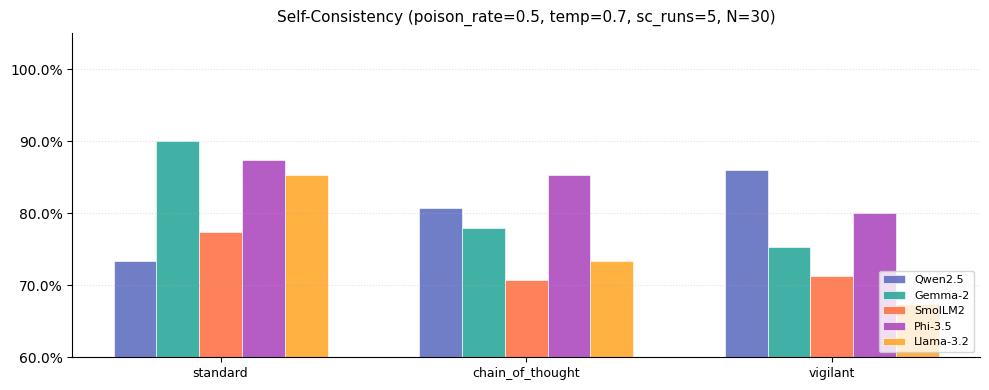

In [12]:
n_models  = len(MODELS)
bar_width = 0.14
x         = np.arange(len(PROMPT_TYPES))
offsets   = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * bar_width

fig, ax = plt.subplots(figsize=(10, 4))
for i, model in enumerate(MODELS):
    sub  = df_sc[df_sc["model"] == model].set_index("prompt_type")
    vals = [sub.loc[pt, "self_consistency"] for pt in PROMPT_TYPES]
    ax.bar(x + offsets[i], vals, bar_width,
           label=MODEL_LABELS[model],
           color=MODEL_COLORS[model],
           edgecolor="white", linewidth=0.5, alpha=0.88)

ax.set_title(f"Self-Consistency (poison_rate=0.5, temp={TEMP_SC}, sc_runs={SC_RUNS}, N={N_SC})",
             fontsize=11, pad=8)
ax.set_xticks(x)
ax.set_xticklabels(PROMPT_TYPES, fontsize=9)
ax.set_ylim(0.6, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle=":", alpha=0.4)
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("../figures/05_self_consistency.png", dpi=150, bbox_inches="tight")
print("Saved -> figures/05_self_consistency.png")
plt.show()

## 11. Report-Ready Summary Tables

Compact pivot tables for inclusion in the final report.

In [13]:
# Table 1: Accuracy pivot (model x prompt rows, poison_rate columns)
pivot_acc = df_main.pivot_table(index=["model", "prompt_type"], columns="poison_rate", values="accuracy")
pivot_acc.columns = [f"{c:.0%}" for c in pivot_acc.columns]
pivot_acc.index = pivot_acc.index.map(lambda x: (MODEL_LABELS[x[0]], x[1]))
print("=== Table 1: Accuracy by Condition ===")
print(pivot_acc.to_string(float_format="{:.3f}".format))

# Table 2: Macro-F1 pivot
pivot_f1 = df_main.pivot_table(index=["model", "prompt_type"], columns="poison_rate", values="macro_f1")
pivot_f1.columns = [f"{c:.0%}" for c in pivot_f1.columns]
pivot_f1.index = pivot_f1.index.map(lambda x: (MODEL_LABELS[x[0]], x[1]))
print("\n=== Table 2: Macro-F1 by Condition ===")
print(pivot_f1.to_string(float_format="{:.3f}".format))

# Table 3: Hallucination rate pivot
pivot_hall = df_main.pivot_table(index=["model", "prompt_type"], columns="poison_rate", values="hallucination_rate")
pivot_hall.columns = [f"{c:.0%}" for c in pivot_hall.columns]
pivot_hall.index = pivot_hall.index.map(lambda x: (MODEL_LABELS[x[0]], x[1]))
print("\n=== Table 3: Hallucination Rate by Condition ===")
print(pivot_hall.to_string(float_format="{:.3f}".format))

# Table 4: Self-consistency (single poison_rate=0.5)
sc_table = df_sc.copy()
sc_table["model"] = sc_table["model"].map(MODEL_LABELS)
sc_table = sc_table.set_index(["model", "prompt_type"])
print(f"\n=== Table 4: Self-Consistency (poison_rate=0.5, temp={TEMP_SC}, sc_runs={SC_RUNS}) ===")
print(sc_table.to_string(float_format="{:.3f}".format))

=== Table 1: Accuracy by Condition ===
                              0%   25%   50%   75%  100%
model     prompt_type                                   
SmolLM2   chain_of_thought 0.340 0.460 0.300 0.420 0.360
          standard         0.340 0.340 0.340 0.340 0.340
          vigilant         0.380 0.400 0.520 0.360 0.480
Qwen2.5   chain_of_thought 0.580 0.540 0.500 0.500 0.500
          standard         0.500 0.420 0.500 0.440 0.420
          vigilant         0.360 0.340 0.320 0.360 0.340
Gemma-2   chain_of_thought 0.560 0.500 0.480 0.560 0.500
          standard         0.700 0.660 0.600 0.580 0.540
          vigilant         0.400 0.360 0.440 0.480 0.420
Llama-3.2 chain_of_thought 0.520 0.480 0.400 0.480 0.460
          standard         0.520 0.500 0.480 0.500 0.460
          vigilant         0.360 0.320 0.320 0.380 0.320
Phi-3.5   chain_of_thought 0.780 0.560 0.620 0.580 0.520
          standard         0.680 0.660 0.600 0.620 0.580
          vigilant         0.740 0.540 0.520 0.52

## Key Findings

**Model ranking** (mean accuracy, all prompts and poison rates): Phi-3.5 (0.587) > Gemma-2 (0.505) > Llama-3.2 (0.441) ≈ Qwen2.5 (0.433) > SmolLM2 (0.379).

**F1 — Monotonic degradation; no parametric fallback.**  
All five models degrade monotonically with poison rate. At poison_rate=1.0 (P@k=0), models default to NOT ENOUGH INFO rather than leveraging parametric knowledge. No U-shaped recovery is observed.

**F2 — Phi-3.5 leads; SmolLM2 ignores context.**  
Phi-3.5 CoT reaches 0.780 at clean baseline — highest single-condition value. SmolLM2 standard flatlines at 0.340 across all poison rates, suggesting it relies on prior probabilities rather than retrieved passages.

**F3 — CoT best on average; vigilant consistently underperforms.**  
Mean accuracy across 5 models and all rates: CoT 0.519 > standard 0.482 > vigilant 0.406. CoT benefits Phi-3.5 and Llama-3.2 most (+5-7pp vs standard).

**F4 — Vigilant helps only Phi-3.5.**  
Qwen2.5, SmolLM2, and Llama-3.2 perform near-random under vigilant. Structured consistency-check instructions require a minimum instruction-following capability to function as intended.

**F5 — SmolLM2/vigilant has catastrophic hallucination (0.706-0.882).**  
Highest values in the grid. The vigilant prompt's cross-checking step actively misleads a model that cannot reason reliably.

**F6 — Hallucination decreases with poison rate.**  
As poison rate grows, models abstain to NOT ENOUGH INFO, reducing false assertions. The 0-50% regime is the most dangerous: models partially trust corrupted context and over-assert.

**F7 — Self-consistency range: 0.673 (Llama-3.2/CoT) to 0.900 (Gemma-2/standard).**  
Smaller models under CoT are most sensitive to passage-order perturbation. High self-consistency does not imply high accuracy (e.g. Qwen2.5/vigilant: SC=0.860, accuracy=0.344).

**F8 — P@k and accuracy are not significantly correlated (global Pearson r=0.169, p=0.146).**  
Retrieval quality does not predict generation accuracy, consistent with models being weakly grounded in retrieved passages. This holds across all prompt types and is strongest for vigilant (r=0.082, Spearman=0.000).